In [2]:
from skimage import io
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import glob
from sklearn.decomposition import PCA
from skimage.transform import SimilarityTransform
from skimage.transform import warp
import os
import pathlib

## Preprocess images
The data comes from (https://www.kaggle.com/datasets/crawford/cat-dataset) and we will use a subset of the images.

For each photo there is also a landmark file with up to nine landmarks. We will use the first three landmarks: left eye, right eye and mouth.

In [3]:
def read_landmark_file(file_name):
    f = open(file_name, "r")
    lm_s = f.readline().strip().split(" ")
    # First value is the number of variables
    n_lms = int(lm_s[0])
    if n_lms < 3:
        print(f"Not enough landmarks found")
        return None

    new_lms = 3
    # 3 landmarks each with (x,y)
    lm = np.zeros((new_lms, 2))
    for i in range(new_lms):
        lm[i, 0] = lm_s[1 + i * 2]
        lm[i, 1] = lm_s[2 + i * 2]
    return lm

In [4]:
def align_and_crop_one_cat_to_destination_cat(img_src, lm_src, img_dst, lm_dst):
    """
    Landmark based alignment of one cat image to a destination
    :param img_src: Image of source cat
    :param lm_src: Landmarks for source cat
    :param lm_dst: Landmarks for destination cat
    :return: Warped and cropped source image. None if something did not work
    """
    tform = SimilarityTransform()
    tform.estimate(lm_src, lm_dst)
    warped = warp(img_src, tform.inverse, output_shape=img_dst.shape)

    # Center of crop region
    cy = 185
    cx = 210
    # half the size of the crop box
    sz = 180
    # Create box to crop
    warp_crop = warped[cy - sz : cy + sz, cx - sz : cx + sz]
    shape = warp_crop.shape
    if shape[0] == sz * 2 and shape[1] == sz * 2:
        return img_as_ubyte(warp_crop)
    else:
        print(
            f"Could not crop image. It has shape {shape}. Probably too close to border of image"
        )
        return None

In [5]:
def preprocess_all_cats(in_dir, out_dir):
    """
    Create aligned and cropped version of image
    :param in_dir: Where are the original photos and landmark files
    :param out_dir: Where should the preprocessed files be placed
    """
    dst = "data/ModelCat"
    dst_lm = read_landmark_file(f"{dst}.jpg.cat")
    dst_img = io.imread(f"{dst}.jpg")

    all_images = glob.glob(in_dir + "*.jpg")
    for img_idx in all_images:
        name_no_ext = os.path.splitext(img_idx)[0]
        base_name = os.path.basename(name_no_ext)
        out_name = f"{out_dir}/{base_name}_preprocessed.jpg"

        src_lm = read_landmark_file(f"{name_no_ext}.jpg.cat")
        src_img = io.imread(f"{name_no_ext}.jpg")

        proc_img = align_and_crop_one_cat_to_destination_cat(
            src_img, src_lm, dst_img, dst_lm
        )
        if proc_img is not None:
            io.imsave(out_name, proc_img)

In [6]:
def preprocess_one_cat():
    src = "data/MissingCat"
    dst = "data/ModelCat"
    out = "data/MissingCatProcessed.jpg"

    src_lm = read_landmark_file(f"{src}.jpg.cat")
    dst_lm = read_landmark_file(f"{dst}.jpg.cat")

    src_img = io.imread(f"{src}.jpg")
    dst_img = io.imread(f"{dst}.jpg")

    src_proc = align_and_crop_one_cat_to_destination_cat(
        src_img, src_lm, dst_img, dst_lm
    )
    if src_proc is None:
        return

    io.imsave(out, src_proc)

    fig, ax = plt.subplots(ncols=3, figsize=(16, 6))
    ax[0].imshow(src_img)
    ax[0].plot(src_lm[:, 0], src_lm[:, 1], ".r", markersize=12)
    ax[1].imshow(dst_img)
    ax[1].plot(dst_lm[:, 0], dst_lm[:, 1], ".r", markersize=12)
    ax[2].imshow(src_proc)
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()

In [7]:
def create_u_byte_image_from_vector(im_vec, height, width, channels):
    min_val = im_vec.min()
    max_val = im_vec.max()

    # Transform to [0, 1]
    im_vec = np.subtract(im_vec, min_val)
    im_vec = np.divide(im_vec, max_val - min_val)
    im_vec = im_vec.reshape(height, width, channels)
    im_out = img_as_ubyte(im_vec)
    return im_out

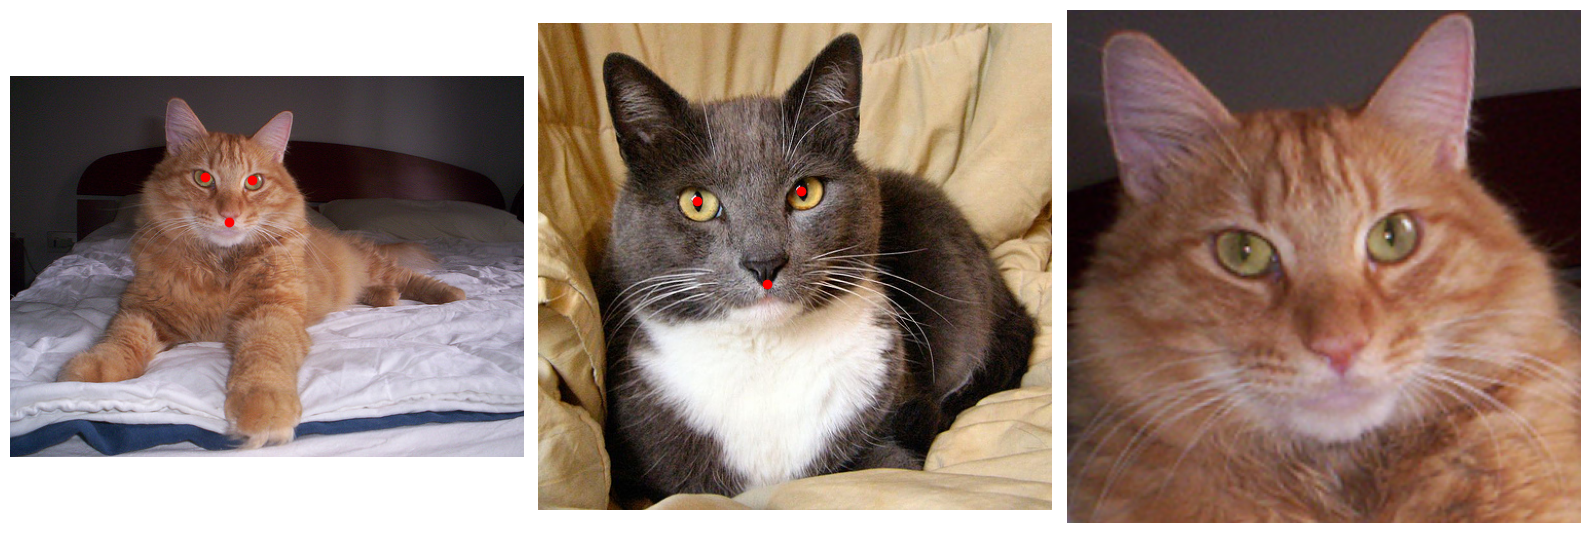

In [7]:
preprocess_one_cat()

In [8]:
input_dir = "training_data/"
output_dir = "processed_data/"

In [9]:
preprocess_all_cats(input_dir, output_dir)

KeyboardInterrupt: 

## Gathering data into data matrix
The data matrix can be constructed by:

* Find the number of image files in the preprocessed folder using glob. Look at the preprocess_all_cats function to get an idea of how to use glob.
* Read the first photo and use that to find the height and width of the photos
* Set n_samples and n_features
Make an empty matrix data_matrix = np.zeros((n_samples, n_features))
* Read the image files one by one and use flatten() to make each image into a 1-D vector (flat_img).
* Put the image vector (flat_img) into the data matrix by for example data_matrix[idx, :] = flat_img , where idx is the index of the current image.


In [9]:
processed_cat_dir = output_dir
all_images = glob.glob(processed_cat_dir + "*.jpg")
all_images[0]

'processed_data/00000036_029_preprocessed.jpg'

In [10]:
first_img_name = "/00000001_000_preprocessed.jpg"
first_img = io.imread(processed_cat_dir + first_img_name)
img_height = first_img.shape[0]
img_width = first_img.shape[1]
img_height, img_width, first_img.flatten().shape[0]

(360, 360, 388800)

In [11]:
n_samples = 100
# Since all the images are the same size
n_features = first_img.ravel().shape[0]
data_matrix = np.zeros((n_samples, n_features), dtype=np.uint8)
data_matrix.shape

(100, 388800)

In [12]:
# Flatten all the cats
for i in range(n_samples):
    cat_image_name = all_images[i]
    cat_img = io.imread(cat_image_name)
    flatten_cat = cat_img.flatten()
    data_matrix[i, :] = flatten_cat
    if i % 20 == 0:
        print(f"flattened {i + 1} cats")
data_matrix[0, :]

flattened 1 cats
flattened 21 cats
flattened 41 cats
flattened 61 cats
flattened 81 cats


array([234, 214, 179, ...,  17,  16,  21], dtype=uint8)

## Compute and visualize a mean cat

In [13]:
mean_cat = np.mean(data_matrix, axis=0)
mean_cat

array([104.75,  97.54,  83.39, ..., 108.47, 101.69,  92.35])

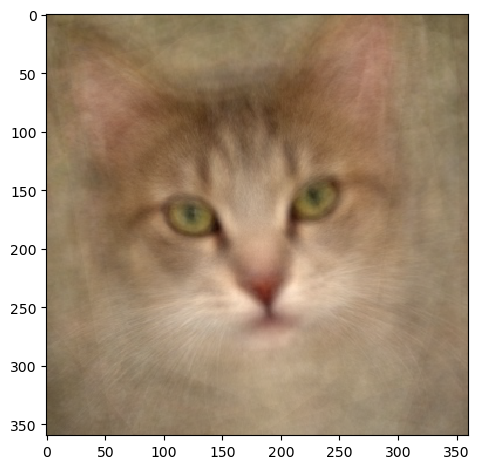

In [14]:
mean_cat_img = create_u_byte_image_from_vector(
    mean_cat, 360,
    360,
    3,
)
io.imshow(mean_cat_img)


## Get a new cat

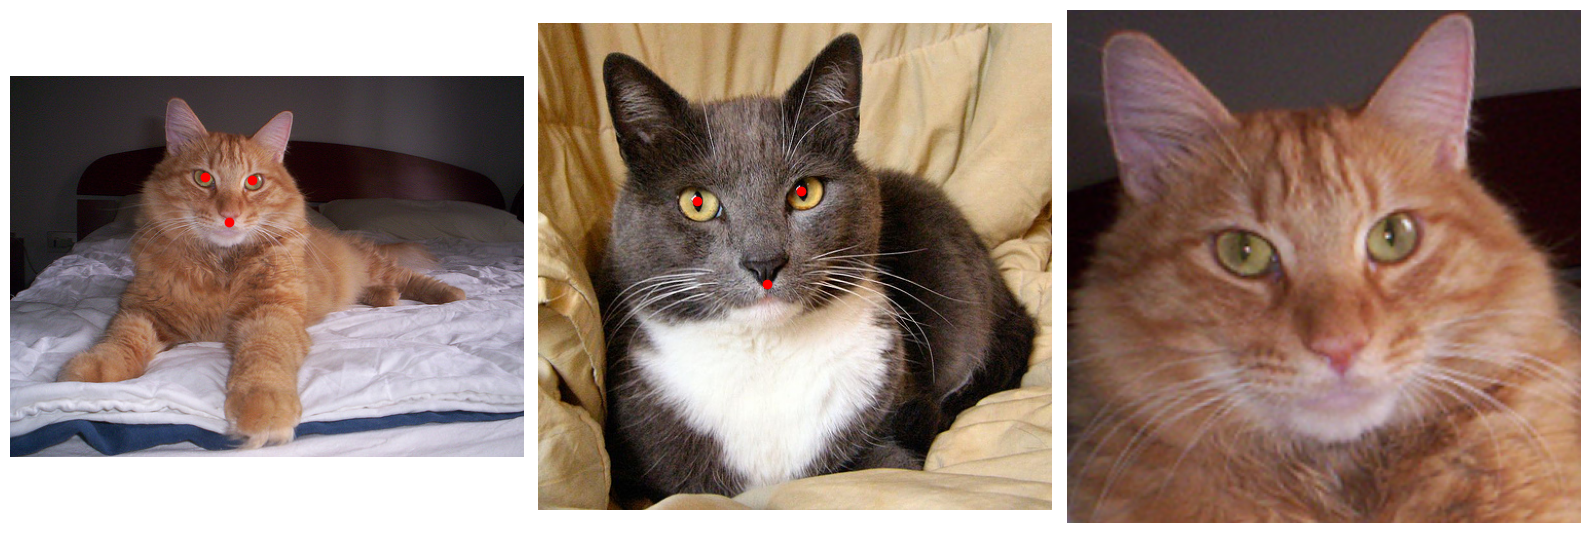

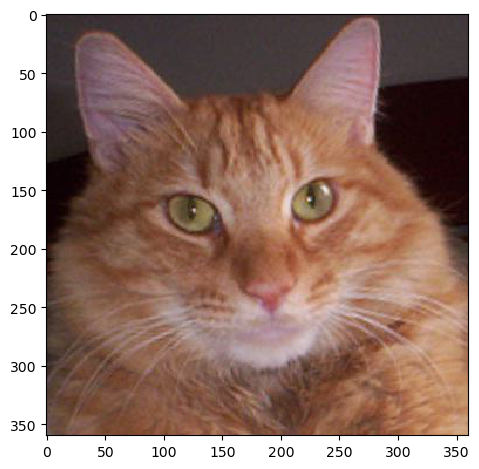

In [15]:
preprocess_one_cat()
missing_cat = io.imread("data/MissingCatProcessed.jpg")
io.imshow(missing_cat)

In [23]:
missing_flat_cat = missing_cat.flatten()
sub_data = data_matrix - missing_flat_cat
sub_distances = np.linalg.norm(sub_data, axis=1)
closest_cat = np.argmin(sub_data, axis=0)
sub_data.shape, sub_data, closest_cat

((100, 388800),
 array([[180, 170, 127, ...,  71, 113, 160],
        [196, 208, 199, ..., 170, 199, 194],
        [223, 226, 210, ..., 197, 241,  29],
        ...,
        [202, 212, 204, ...,  54,  97, 139],
        [ 24,  10,   0, ...,  54,  97, 139],
        [202, 212, 204, ...,  54,  97, 139]], dtype=uint8),
 array([94, 21, 98, ..., 35, 76, 92]))

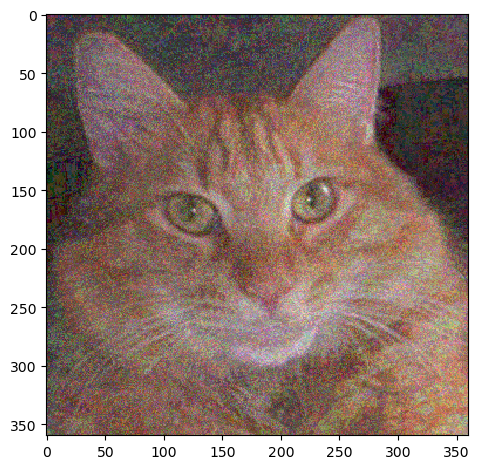

In [25]:
closest_cat_img = create_u_byte_image_from_vector(
    closest_cat + missing_flat_cat,
    360,
    360,
    3,
)
io.imshow(closest_cat_img)

## PCA analysis on cats

In [27]:
print("Computing PCA")
cats_pca = PCA(n_components=50)
cats_pca.fit(data_matrix)

Computing PCA


PCA(n_components=50)

In [29]:
cats_pca.explained_variance_ratio_.shape

(50,)

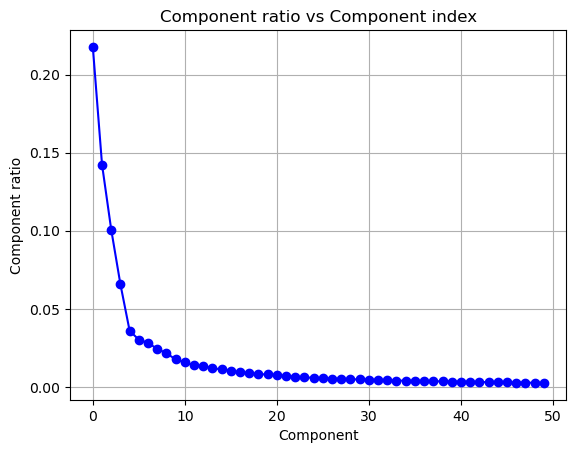

In [33]:
ratio = cats_pca.explained_variance_ratio_
plt.plot(list(range(len(ratio))), ratio, marker="o", linestyle="-", color="b")
plt.title("Component ratio vs Component index")
plt.xlabel("Component")
plt.ylabel("Component ratio")
plt.grid(True)
plt.show()

In [ ]:
components = cats_pca.transform(data_matrix)

Now each cat has a position in PCA space. For each cat this position is 50-dimensional vector. Each value in this vector describes how much of that component is present in that cat photo.

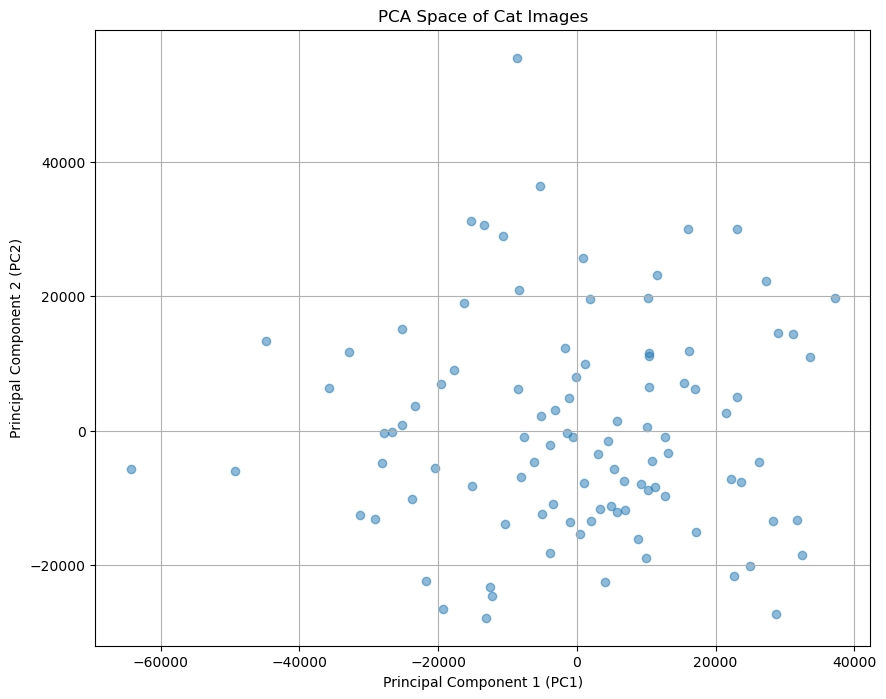

In [39]:
# plot the first two dimensions of the PCA space, to see where the cats are placed.
pc_1 = components[:, 0]
pc_2 = components[:, 1]
plt.figure(figsize=(10, 8))
plt.scatter(pc_1, pc_2, alpha=0.5)
plt.title("PCA Space of Cat Images")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True)
plt.show()

## Extreme cats

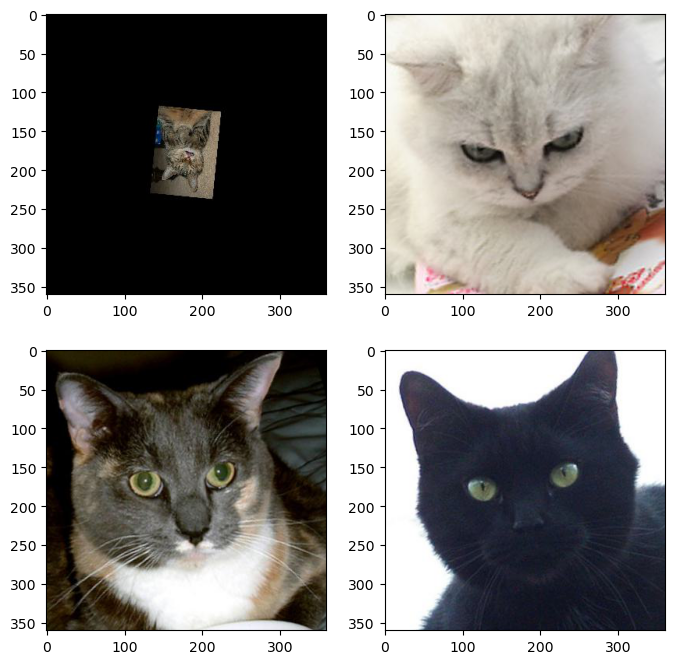

In [45]:
extreme_min_1 = np.argmin(pc_1)
extreme_max_1 = np.argmax(pc_1)
extreme_min_2 = np.argmin(pc_2)
extreme_max_2 = np.argmax(pc_2)
sus_cats_ids = [extreme_min_1, extreme_max_1, extreme_min_2, extreme_max_2]
fig, axes = plt.subplots(2, 2, figsize=(8,8))
axes = axes.ravel()
for i, sus_cat in enumerate(sus_cats_ids):
    sus_cat_name = all_images[sus_cat]
    sus_cat_img = io.imread(sus_cat_name)
    axes[i].imshow(sus_cat_img)


## Synthesize cat
![formula](images/image.png)

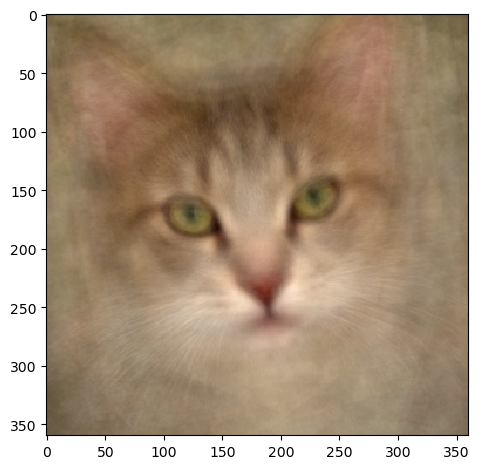

In [57]:
weight1 = 0.2
weight2 = 0.4
synth_cat = mean_cat + weight1 * cats_pca.components_[0, :] + weight2 * cats_pca.components_[1, :]
synth_img = create_u_byte_image_from_vector(
    synth_cat,
    360,
    360,
    3,
)
io.imshow(synth_img)

A very useful method to get an overview of the major modes of variation in a dataset is to synthesize the samples that are lying on the outer edges of the PCA space.

If we for example move a distance out of the first principal axis we can synthesize the cat image there. In this case we will try to move to 
±sqrt(explained variance), where explained variance is the variance explained by that principal component. In code, this will look like:

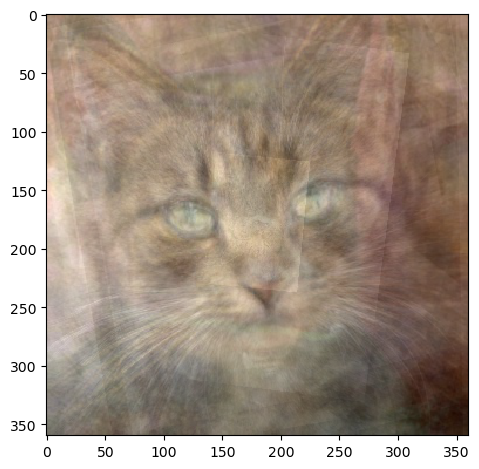

In [ ]:
# here m is the principal component that we are investigating
m = 0
synth_cat_plus = (
    mean_cat
    + 3 * np.sqrt(cats_pca.explained_variance_[m]) * cats_pca.components_[m, :]
)
synth_plus_img = create_u_byte_image_from_vector(
    synth_cat_plus,
    360,
    360,
    3,
)
synth_cat_minus = (
    mean_cat
    - 3 * np.sqrt(cats_pca.explained_variance_[m]) * cats_pca.components_[m, :]
)
synth_minus_img = create_u_byte_image_from_vector(
    synth_cat_minus,
    360,
    360,
    3,
)

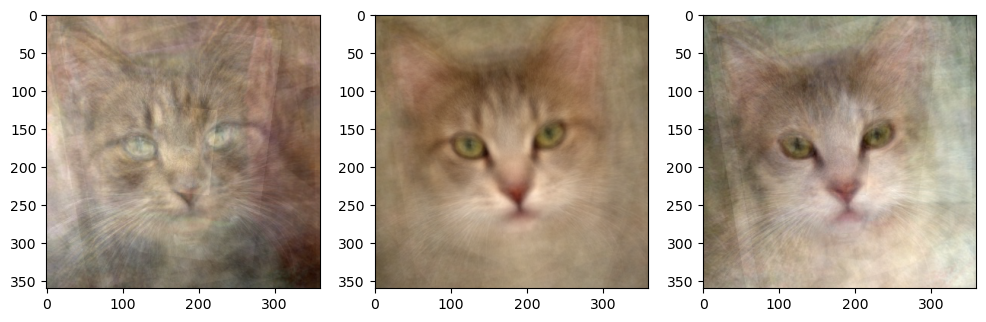

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(12, 12))
axes[0].imshow(synth_minus_img)
axes[1].imshow(mean_cat_img)
axes[2].imshow(synth_plus_img)
plt.show()
# If you're only seeing the last image, it's likely because each call to imshow() is overwriting the previous plot since you're not properly setting up the subplot structure. Let's fix this. Here's a complete, working version:

## Eigencats

In [71]:
import random

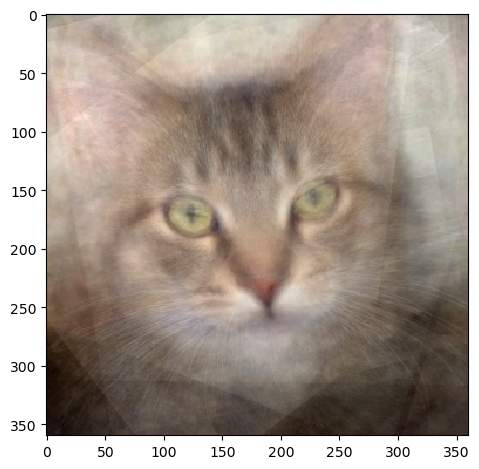

In [80]:
n_components_to_use = 5
synth_cat = mean_cat
for idx in range(n_components_to_use):
    w = random.uniform(-1, 1) * 3 * np.sqrt(cats_pca.explained_variance_[idx])
    synth_cat = synth_cat + w * cats_pca.components_[idx, :]
synth_img = create_u_byte_image_from_vector(
    synth_cat,
    360,
    360,
    3,
)
io.imshow(synth_img)

## The missing cat problem
We could find similar cats by computing the difference between the missing cat and all the photos in the database

In [84]:
im_miss = io.imread("figures/MissingCatProcessed.jpg")
im_miss_flat = im_miss.flatten()
# -1 is a special value that tells NumPy to automatically figure out the size of that dimension based on the total number of elements.
im_miss_flat = im_miss_flat.reshape(1, -1)
pca_coords = cats_pca.transform(im_miss_flat)
pca_coords = pca_coords.flatten()
pca_coords[0], pca_coords[1]

(-7636.512510854343, -14751.959938024516)

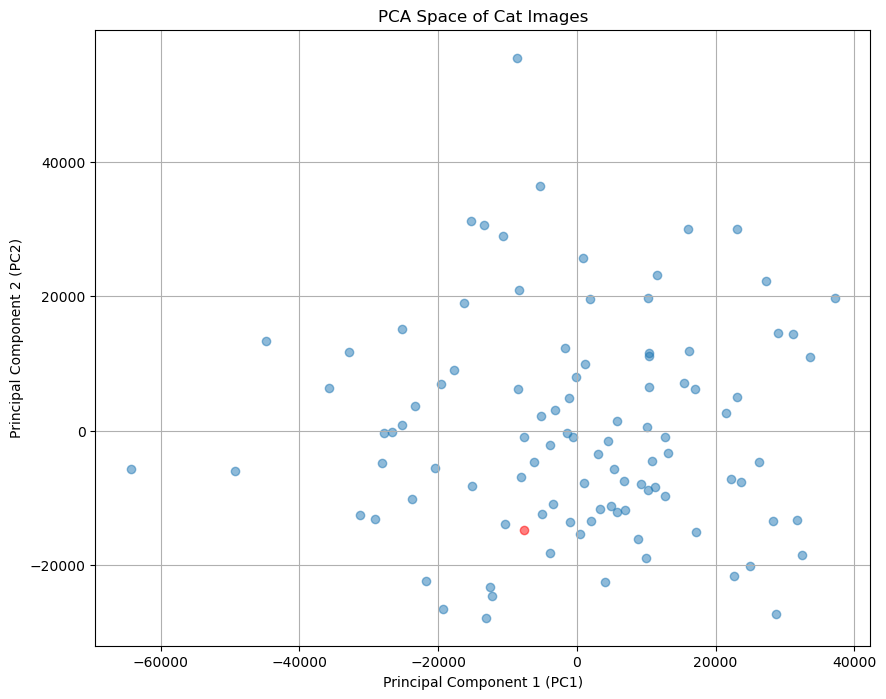

In [85]:
# plot the first two dimensions of the PCA space, to see where the cats are placed.
pc_1 = components[:, 0]
pc_2 = components[:, 1]
plt.figure(figsize=(10, 8))
plt.scatter(pc_1, pc_2, alpha=0.5)
plt.scatter(pca_coords[0], pca_coords[1], alpha=0.5, color="r")
plt.title("PCA Space of Cat Images")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True)
plt.show()

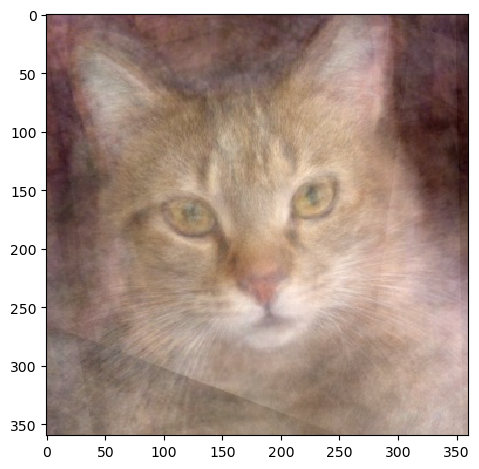

In [91]:
n_components_to_use = 40
synth_cat = mean_cat
for idx in range(n_components_to_use):
    synth_cat = synth_cat + pca_coords[idx] * cats_pca.components_[idx, :]
synth_img = create_u_byte_image_from_vector(
    synth_cat,
    360,
    360,
    3,
)
io.imshow(synth_img)

## Find closest cats - look like missing cat

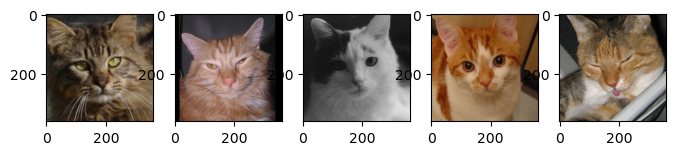

In [100]:
comp_sub = components - pca_coords
pca_distances = np.linalg.norm(comp_sub, axis=1)
n = 5
n_closest = np.argpartition(pca_distances, 5)[:n]
fig, axes = plt.subplots(1,5, figsize=(8, 8))
axes = axes.ravel()
for i, neighbour_cat in enumerate(n_closest):
    neighbour_cat_name = all_images[neighbour_cat]
    neighbour_cat_img = io.imread(neighbour_cat_name)
    axes[i].imshow(neighbour_cat_img)